<a href="https://colab.research.google.com/github/AtufaMehboob59/Retail_Sales_Analytics_Using_Python/blob/main/Retail_Sales_Analytics_using_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta



In [66]:
# read dataset
df = pd.read_csv("https://github.com/YBIFoundation/Visualization/raw/main/RealTimeRetailSalesAnalytics.csv")

In [67]:
df.head()

,Transaction_ID,Timestamp,Category,Product,Quantity,Unit Price,Discount (%),Sales Amount,City,Payment Mode
0,1001,2026-07-25 13:49:10,Grocery,Tea,4,350,10,1260.0,Kolkata,Credit Card
1,1002,2026-07-25 13:49:10,Electronics,Mobile,4,25000,20,80000.0,Mumbai,Debit Card
2,1003,2026-07-25 13:49:10,Fashion,Shoes,5,4500,0,22500.0,Delhi,UPI
3,1004,2026-07-25 13:49:10,Fashion,Shirt,1,1200,20,960.0,Pune,Cash
4,1005,2026-07-25 13:49:10,Electronics,Tablet,1,18000,10,16200.0,Chennai,Cash


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  1000 non-null   int64  
 1   Timestamp       1000 non-null   object 
 2   Category        1000 non-null   object 
 3   Product         1000 non-null   object 
 4   Quantity        1000 non-null   int64  
 5   Unit Price      1000 non-null   int64  
 6   Discount (%)    1000 non-null   int64  
 7   Sales Amount    1000 non-null   float64
 8   City            1000 non-null   object 
 9   Payment Mode    1000 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


In [69]:
df.describe()

,Transaction_ID,Quantity,Unit Price,Discount (%),Sales Amount
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1500.500000,3.050000,7175.500000,10.08000,19475.857500
std,288.819436,1.393356,14199.046758,7.02089,42558.107198
min,1001.000000,1.000000,45.000000,0.00000,36.000000
25%,1250.750000,2.000000,350.000000,5.00000,933.750000
50%,1500.500000,3.000000,2200.000000,10.00000,5300.000000
75%,1750.250000,4.000000,5500.000000,15.00000,15200.000000
max,2000.000000,5.000000,65000.000000,20.00000,325000.000000


In [70]:
# change datatype of timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Transaction_ID  1000 non-null   int64         
 1   Timestamp       1000 non-null   datetime64[ns]
 2   Category        1000 non-null   object        
 3   Product         1000 non-null   object        
 4   Quantity        1000 non-null   int64         
 5   Unit Price      1000 non-null   int64         
 6   Discount (%)    1000 non-null   int64         
 7   Sales Amount    1000 non-null   float64       
 8   City            1000 non-null   object        
 9   Payment Mode    1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 78.3+ KB


In [72]:
# create hour column
df['Hour'] = df['Timestamp'].dt.hour

In [73]:
df['Hour'].head()

,Hour
0,13
1,13
2,13
3,13
4,13


In [74]:
# create date column
df['Date'] = df['Timestamp'].dt.date

In [75]:
df['Date'].head()

,Date
0,2026-07-25
1,2026-07-25
2,2026-07-25
3,2026-07-25
4,2026-07-25


In [76]:
df.head()

,Transaction_ID,Timestamp,Category,Product,Quantity,Unit Price,Discount (%),Sales Amount,City,Payment Mode,Hour,Date
0,1001,2026-07-25 13:49:10,Grocery,Tea,4,350,10,1260.0,Kolkata,Credit Card,13,2026-07-25
1,1002,2026-07-25 13:49:10,Electronics,Mobile,4,25000,20,80000.0,Mumbai,Debit Card,13,2026-07-25
2,1003,2026-07-25 13:49:10,Fashion,Shoes,5,4500,0,22500.0,Delhi,UPI,13,2026-07-25
3,1004,2026-07-25 13:49:10,Fashion,Shirt,1,1200,20,960.0,Pune,Cash,13,2026-07-25
4,1005,2026-07-25 13:49:10,Electronics,Tablet,1,18000,10,16200.0,Chennai,Cash,13,2026-07-25


In [77]:
# Calculate KPI
total_revenue = df['Sales Amount'].sum()

In [78]:
# total transactions
total_transactions = len(df)

In [79]:
# Average Order
average_order = df['Sales Amount'].mean()

In [80]:
# total quantity
total_quantity = df['Quantity'].sum()

In [81]:
# Product Wise Total Sales
top_products = df.groupby("Product")['Sales Amount'].sum()

In [82]:
# Category eise sales total

category_sales = df.groupby("Category")['Sales Amount'].sum()

In [83]:
# City wise sales amount
city_sales = df.groupby('City')['Sales Amount'].sum()

In [84]:
# payment mode
payment = df['Payment Mode'].value_counts()

In [85]:
# hour wise sales amount
hourly_sales = df.groupby("Hour")['Sales Amount']

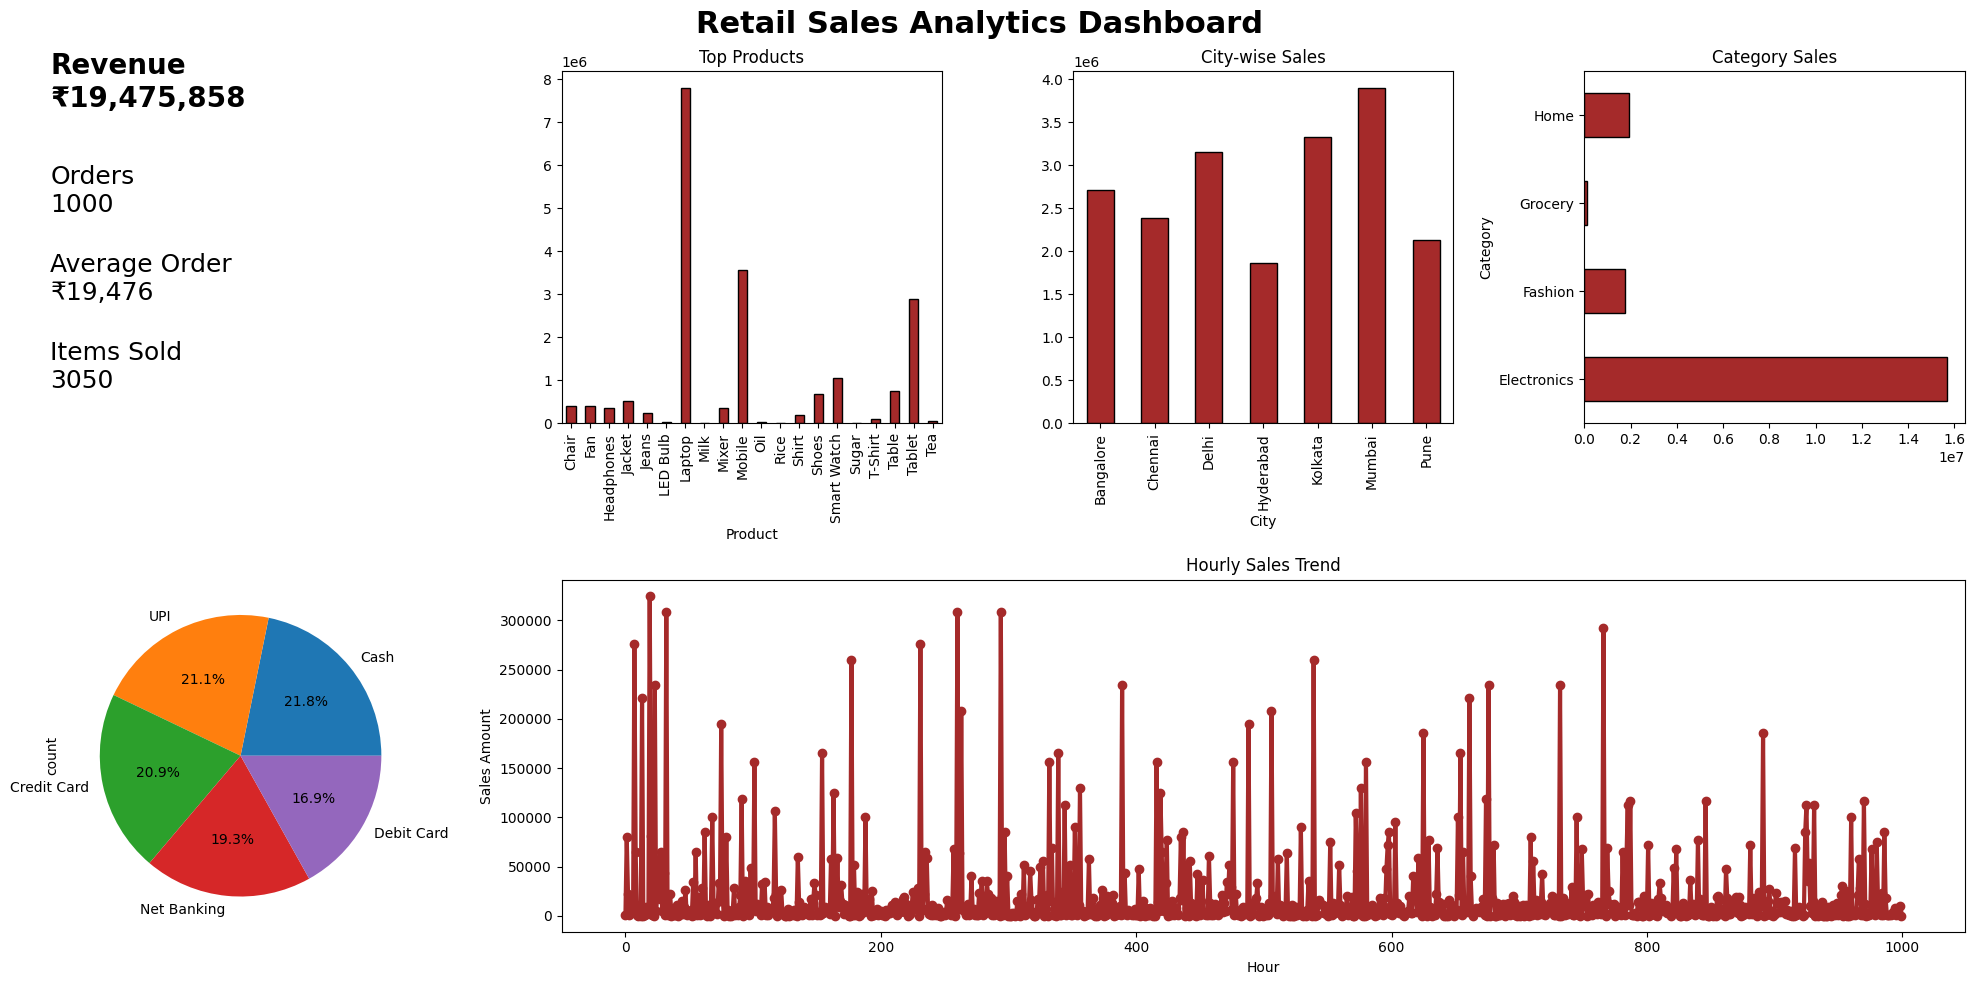

In [86]:
# Create Dashboard

plt.figure(figsize=(20,10))

# ------------------------------------
# KPI Card
# ------------------------------------


ax1 = plt.subplot(2,4,1)

ax1.axis("off")

ax1.text(0,0.90,
         f"Revenue\n₹{total_revenue:,.0f}",
         fontsize=20,
         fontweight="bold")

ax1.text(0,0.60,
         f"Orders\n{total_transactions}",
         fontsize=18)

ax1.text(0,0.35,
         f"Average Order\n₹{average_order:,.0f}",
         fontsize=18)

ax1.text(0,0.10,
         f"Items Sold\n{total_quantity}",
         fontsize=18)

# ------------------------------------
# Top Products
# ------------------------------------

ax2 = plt.subplot(2,4,2)

top_products.plot(
    kind="bar",
    color = 'brown',
    edgecolor = 'black',
    ax=ax2
)

ax2.set_title("Top Products")

# ------------------------------------
# Top Cities
# ------------------------------------

ax3 = plt.subplot(2,4,3)

city_sales.plot(
    kind="bar",
    color = 'brown',
    edgecolor = 'black',
    ax=ax3
)

ax3.set_title("City-wise Sales")

# ------------------------------------
# Category Sales
# ------------------------------------

ax4 = plt.subplot(2,4,4)

category_sales.plot(
    kind="barh",
    color = 'brown',
    edgecolor = 'black',
    ax=ax4
)

ax4.set_title("Category Sales")

# ------------------------------------
# Payment Distribution
# ------------------------------------

ax5 = plt.subplot(2,4,5)

payment.plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=ax5
)
# ------------------------------------
# Hourly Sales Trend
# ------------------------------------

ax6 = plt.subplot(2,4,(6,8))

hourly_sales.plot(
    marker="o",
    linewidth=3,
    color = 'brown',
    ax=ax6
)

ax6.set_title("Hourly Sales Trend")
ax6.set_xlabel("Hour")
ax6.set_ylabel("Sales Amount")

plt.suptitle(
    "Retail Sales Analytics Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()